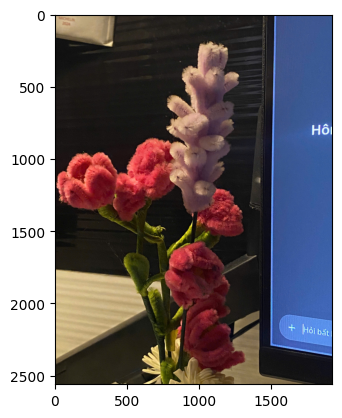

In [18]:
import cv2
import matplotlib.pyplot as plt 

img = cv2.imread("flower_new.png")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

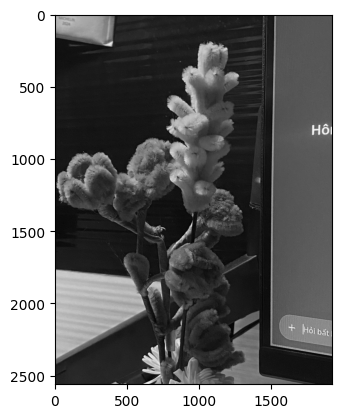

In [19]:
gray_img = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

plt.imshow(gray_img, cmap="gray")

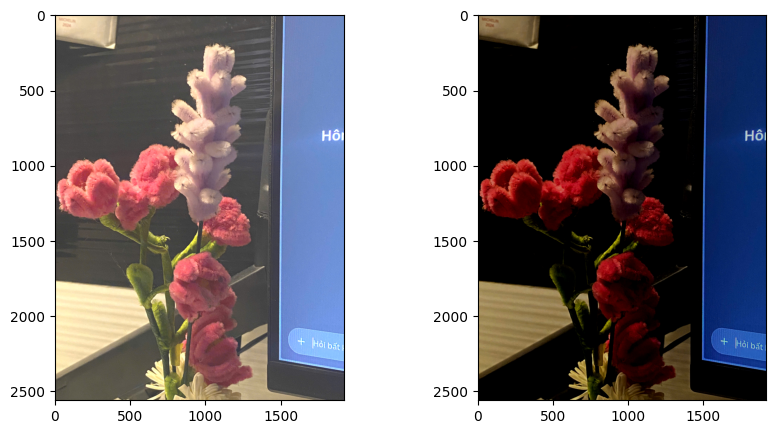

In [20]:
bright_img = cv2.add(img, 50)
dark_img = cv2.subtract(img, 50)

plt.figure(figsize=(10,5))
plt.subplot(121)
plt.imshow(bright_img)

plt.subplot(122)
plt.imshow(dark_img)
plt.show()

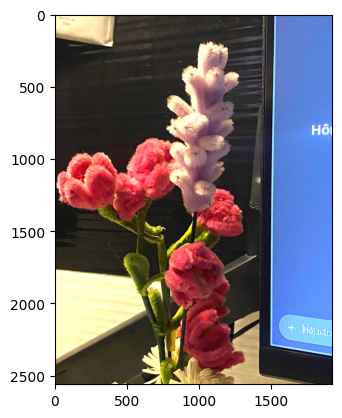

In [21]:
contrast_img = cv2.convertScaleAbs(img, alpha= 1.5, beta = 0)

plt.imshow(contrast_img)

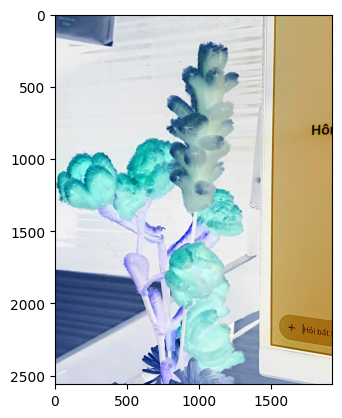

In [22]:
negative_img = 255 - img

plt.imshow(negative_img)

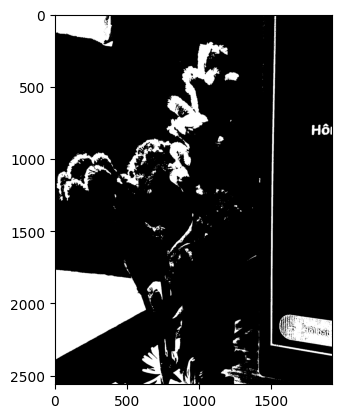

In [23]:
ret, thresh = cv2.threshold(gray_img, 127, 255, cv2.THRESH_BINARY)
plt.imshow(thresh, cmap = "gray")

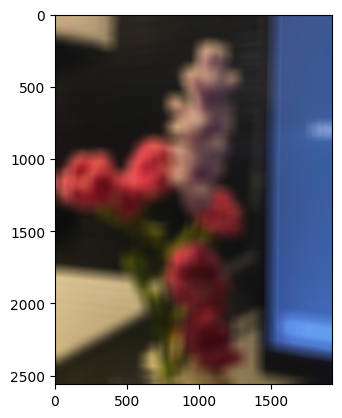

In [24]:
mean_blur = cv2.blur(img, (100,100))

plt.imshow(mean_blur)

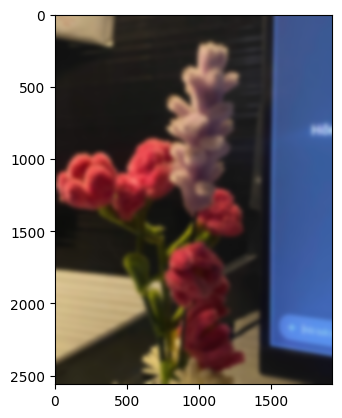

In [25]:
gaussian_blur = cv2.GaussianBlur(img, (99, 99), 0)

plt.imshow(gaussian_blur)

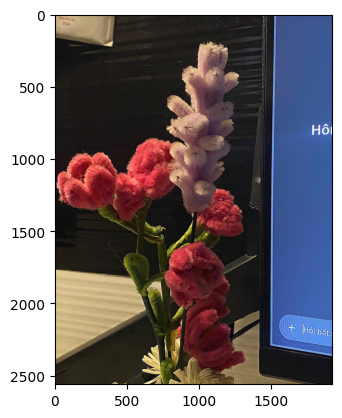

In [26]:
import numpy as np
sharpening_kernel = np.array([[-1,-1,-1],
                              [-1,9,-1],
                              [-1,-1,-1]])
sharpening_img = cv2.filter2D(img, -1, sharpening_kernel)

plt.imshow(sharpening_img)

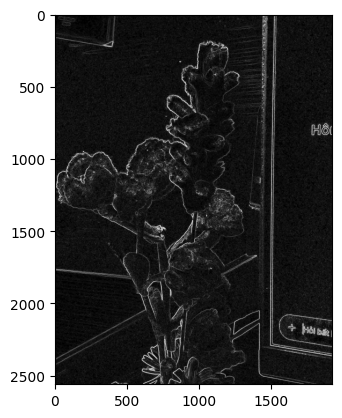

In [28]:

sobelx = cv2.Sobel(gray_img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray_img, cv2.CV_64F, 0, 1, ksize=3)

# tính độ lớn (Magnitude) dạng Float
sobel_combined = cv2.magnitude(sobelx, sobely)

# chuyển kết quả cuối cùng về uint8 để hiển thị
sobel_combined = cv2.convertScaleAbs(sobel_combined)

plt.imshow(sobel_combined, cmap='gray')
plt.show()

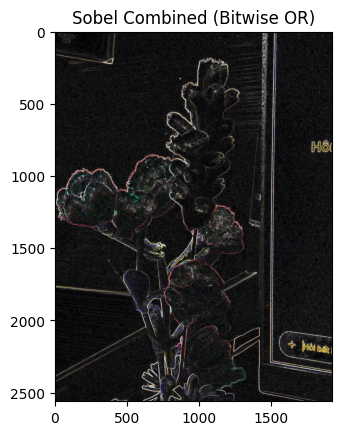

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Tính Sobel (vẫn dùng CV_64F để lấy được cả đạo hàm âm)
sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

# 2. CHUYỂN VỀ UINT8 TRƯỚC (Rất quan trọng cho Bitwise)
# cv2.convertScaleAbs sẽ lấy trị tuyệt đối và ép về uint8
sobelx_8u = cv2.convertScaleAbs(sobelx)
sobely_8u = cv2.convertScaleAbs(sobely)

# 3. Kết hợp bằng Bitwise OR
# Phép toán này sẽ lấy các điểm sáng nhất từ cả 2 ảnh X và Y
sobel_combined = cv2.bitwise_or(sobelx_8u, sobely_8u)

# 4. Hiển thị
plt.imshow(sobel_combined, cmap='gray')
plt.title('Sobel Combined (Bitwise OR)')
plt.show()

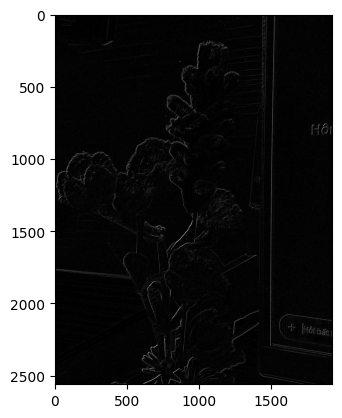

In [33]:
# 1.b. Toán tử Prewitt (tự định nghĩa kernel và áp dụng)
# Định nghĩa Kernel Prewitt cho hướng X (tìm cạnh dọc)
kernel_prewitt_x = np.array([[-1, 0, 1],
                             [-1, 0, 1],
                             [-1, 0, 1]])
# Định nghĩa Kernel Prewitt cho hướng Y (tìm cạnh ngang)
kernel_prewitt_y = np.array([[-1, -1, -1],
                             [ 0,  0,  0],
                             [ 1,  1,  1]])

# Áp dụng bộ lọc
prewitt_x = cv2.filter2D(gray_img, -1, kernel_prewitt_x)
prewitt_y = cv2.filter2D(gray_img, -1, kernel_prewitt_y)
# Kết hợp hai hướng (cộng đơn giản 50-50)
prewitt_final = cv2.addWeighted(prewitt_x, 0.5, prewitt_y, 0.5, 0)

plt.imshow(prewitt_final,cmap= "gray")

Cơ chế: $G \approx \alpha |G_x| + \beta |G_y|$Đặc điểm: Nhanh, giữ được độ sáng vừa phải, nhưng không chính xác về mặt toán học cho các đường chéo (các đường chéo sẽ bị mờ hơn một chút so với đường thẳng tắp).

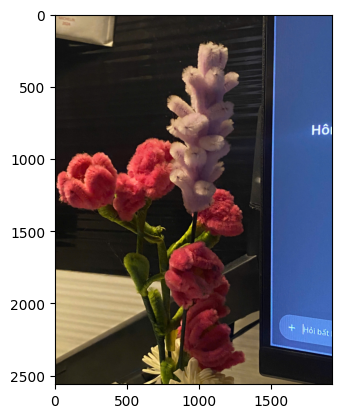

In [38]:
median = cv2.medianBlur(img, 5)

plt.imshow(median)

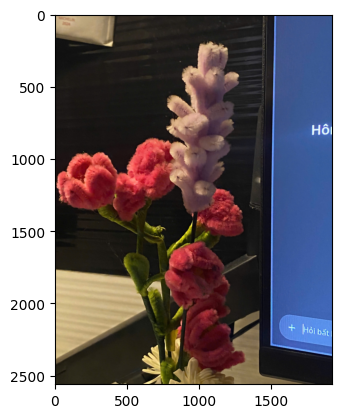

In [40]:
bilateral = cv2.bilateralFilter(img, 9, 75, 75)

plt.imshow(bilateral)
